In [1]:
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU devices
os.environ["TFDS_DATA_DIR"] = os.path.expanduser("~/tensorflow_datasets")  # default location of tfds database
os.environ["KERAS_BACKEND"] = "tensorflow"

import re
import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, TimeDistributed, LSTM

from dpmhm.datasets import transformer, feature, _DTYPE, utils, install

2024-08-08 09:26:14.409368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-08 09:26:14.434476: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-08 09:26:14.434514: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-08 09:26:15.546470: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
TFDS_DATA_DIR = os.path.expanduser('~/tensorflow_datasets/')

_ = install('FEMTO', 
            data_dir=TFDS_DATA_DIR,                           
            manual_dir=os.path.expanduser('~/tmp/ieee-phm-2012-data-challenge-dataset-master/')
            )

2024-08-08 09:26:16.967165: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:
ds0 = tfds.load('FEMTO', split='train')

2024-08-08 09:26:20.783014: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Sort the data by Bearing and by chronologic order

In [4]:
import tensorflow as tf

keys=['RemainingUsefulLife', 'TimeElapsed']

compactor_train = transformer.DatasetCompactor(
    ds0,
    channels=['vibration'], 
    keys=keys,
    resampling_rate=25600, 
    window_size=2560,)

equivalence_labels = compactor_train.full_label_dict

data=[]
for el in list(compactor_train.dataset.as_numpy_iterator()): 
    data.append((el['metadata']['FileName'], el['signal'], el['label']))

# sort by filenames
data_sorted = sorted(data, key=lambda x: x[0])
Name, Spec, Label = zip(*data_sorted)

Name_tensor = tf.constant(Name, dtype=tf.string)
Spec_tensor = tf.constant(Spec, dtype=tf.float32)
Label_tensor = tf.constant(Label, dtype=tf.string)

Name_dataset = tf.data.Dataset.from_tensor_slices(Name_tensor)
Spec_dataset = tf.data.Dataset.from_tensor_slices(Spec_tensor)
Label_dataset = tf.data.Dataset.from_tensor_slices(Label_tensor)

dataset = tf.data.Dataset.zip((Name_dataset, Spec_dataset, Label_dataset))

def to_dict(name, spec, label):
    return {'Name': name, 'Spec': spec, 'Label': label}

dataset = dataset.map(lambda name, spec, label: to_dict(name, spec, label))

dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

2024-08-08 09:26:23.336414: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 09:26:28.461430: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 09:26:28.963842: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 09:26:51.589946: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 09:26:51.593959: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Compute the spectrograms

In [5]:
_func = lambda x, sr: feature.spectral_features(
        x, sr, 'spectrogram',
        time_window=0.025, hop_step=0.0125,
        normalize=False, to_db=True)[0]

@tf.function
def _feature_map(X):
    Xf = tf.py_function(
            func=lambda x: _func(x.numpy(), 25600),
            inp=[X['Spec']],
            Tout=_DTYPE
        )
    Xf.set_shape((2, None, None))
    return Xf, X['Label'], X['Name']

extractor_dataset=dataset.map(_feature_map, num_parallel_calls=tf.data.AUTOTUNE)

Group the data by Bearing and create sequences of length sequence_length. If there is not enough data, the sequence is completed by null data

In [6]:
import tensorflow as tf
import numpy as np

def group_by_bearing(dataset):
    bearings = {}
    for element in dataset:
        file_name = element[2].decode('utf-8')
        bearing_name = file_name.split('/')[0]
        if bearing_name not in bearings:
            bearings[bearing_name] = []
        bearings[bearing_name].append(element)
    return bearings

def create_sequences(data, sequence_length=20):
    sequences = []
    labels = []
    names= []
    for bearing, elements in data.items():
        for i in range(0, len(elements), sequence_length):
            sequence = elements[i:i + sequence_length]
            if len(sequence) < sequence_length:
                sequence += [create_zero_element()] * (sequence_length - len(sequence))
            sequences.append([elem[0] for elem in sequence])
            labels.append([elem[1] for elem in sequence])
            names.append([elem[2] for elem in sequence])
    return np.array(sequences), np.array(labels), np.array(names)

def create_zero_element():
    return [np.zeros((2, 513, 9)), b'', b'']

data_list = list(extractor_dataset.as_numpy_iterator())

grouped_data = group_by_bearing(data_list)

X, y, file_names = create_sequences(grouped_data, sequence_length=20)

2024-08-08 09:27:10.884326: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
X_train=np.zeros((len(X), 20, 513, 9, 2))
y_train=np.zeros((len(X), 20))
Time=np.zeros((len(X), 20))
for i in range(len(X)):
    for j in range(20):
        X_train[i][j]=np.transpose(X[i][j], axes=(1, 2, 0))
        if y[i][j]!=b'':
            y_train[i][j]=equivalence_labels[y[i][j].decode()][0]
            Time[i][j]=equivalence_labels[y[i][j].decode()][1]
        else: 
            y_train[i][j]=0
            Time[i][j]=0

Create the CNN-LSTM model

In [8]:
import keras

model = Sequential([
    TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'), input_shape=(20, 513, 9, 2)),
    TimeDistributed(MaxPooling2D((2, 2), padding='same')),
    TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2), padding='same')),
    TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2), padding='same')),
    TimeDistributed(Flatten()),
    LSTM(10, return_sequences=False),
    Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(0.1), loss='mean_squared_error')
model.summary()

/volatile/home/bm279471/Documents/.venv/lib/python3.11/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 513, 9, 32) │           608 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 257, 5, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 257, 5, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 129, 3, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 129, 3,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 65, 2, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 16640)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10)             │       666,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 759,011 (2.90 MB)

 Trainable params: 759,011 (2.90 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=4,       
    restore_best_weights=True, 
    mode='min'
)

model.fit(X_train, y_train, epochs=200, batch_size=1, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 61s 184ms/step - loss: 151411680.0000 - val_loss: 74459512.0000
Epoch 2/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - loss: 135396912.0000 - val_loss: 72465408.0000
Epoch 3/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 55s 181ms/step - loss: 126876992.0000 - val_loss: 70521320.0000
Epoch 4/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - loss: 106333672.0000 - val_loss: 68646632.0000
Epoch 5/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - loss: 132606944.0000 - val_loss: 66795964.0000
Epoch 6/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 178ms/step - loss: 132317688.0000 - val_loss: 65032092.0000
Epoch 7/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - loss: 142484752.0000 - val_loss: 63330808.0000
Epoch 8/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - loss: 131026432.0000 - val_loss: 61633996.0000
Epoch 9/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - loss: 114584288.0000 - val_loss: 60009876.0000
Epoch 10/200
303/303 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/ste

In [10]:
Bearing_names=['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']

Sort and group by Bearing for the test data

In [11]:
ds1 = tfds.load('FEMTO', split='test')

X_test={}
y_test={}
Time_test={}
labels_test={}
equivalence_labels_test={}
for file in Bearing_names:
    compactor_test = transformer.DatasetCompactor(
        ds1,
        channels=['vibration'], 
        keys=keys,
        resampling_rate=25600, 
        window_size=2560,
        filters={'Bearing' : file})
    
    equivalence_labels_test[file] = compactor_test.full_label_dict
    labels_test[file] = list(compactor_test.full_label_dict.keys())

    data=[]
    for el in list(compactor_test.dataset.as_numpy_iterator()): 
        data.append((el['metadata']['FileName'], el['signal'], el['label']))

    data_sorted = sorted(data, key=lambda x: x[0])
    Name, Spec, Label = zip(*data_sorted)

    Name_tensor = tf.constant(Name, dtype=tf.string)
    Spec_tensor = tf.constant(Spec, dtype=tf.float32)
    Label_tensor = tf.constant(Label, dtype=tf.string)

    Name_dataset = tf.data.Dataset.from_tensor_slices(Name_tensor)
    Spec_dataset = tf.data.Dataset.from_tensor_slices(Spec_tensor)
    Label_dataset = tf.data.Dataset.from_tensor_slices(Label_tensor)

    dataset = tf.data.Dataset.zip((Name_dataset, Spec_dataset, Label_dataset))

    def to_dict(name, spec, label):
        return {'Name': name, 'Spec': spec, 'Label': label}

    dataset = dataset.map(lambda name, spec, label: to_dict(name, spec, label))

    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

    _func = lambda x, sr: feature.spectral_features(
        x, sr, 'spectrogram',
        time_window=0.025, hop_step=0.0125,
        normalize=False, to_db=True)[0]

    @tf.function
    def _feature_map(X):
        Xf = tf.py_function(
                func=lambda x: _func(x.numpy(), 25600),
                inp=[X['Spec']],
                Tout=_DTYPE
            )
        Xf.set_shape((2, None, None))
        return Xf, X['Label'], X['Name']

    extractor_dataset=dataset.map(_feature_map, num_parallel_calls=tf.data.AUTOTUNE)

    data_list = list(extractor_dataset.as_numpy_iterator())

    grouped_data = group_by_bearing(data_list)

    X_, y_, file_names = create_sequences(grouped_data, sequence_length=20)

    X_train=np.zeros((len(X_), 20, 513, 9, 2))
    y_train=np.zeros((len(X_), 20))
    Time=np.zeros((len(X_), 20))
    for i in range(len(X_)):
        for j in range(20):
            X_train[i][j]=np.transpose(X_[i][j], axes=(1, 2, 0))
            if y_[i][j]!=b'':
                y_train[i][j]=equivalence_labels_test[file][y_[i][j].decode()][0]
                Time[i][j]=equivalence_labels_test[file][y_ [i][j].decode()][1]
            else: 
                y_train[i][j]=0
                Time[i][j]=0

    X_test[file], y_test[file] = X_train, y_train
    Time_test[file]=Time

2024-08-08 11:00:16.745206: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 11:00:18.232675: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 11:00:18.505729: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 11:00:23.017845: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 11:00:23.021139: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 11:00:27.749361: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-08-08 11:00:29.028344: W tensorflow/core/framework/local_rendezvous.cc:404] L

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 988ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 483ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


/tmp/ipykernel_428137/1434571568.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


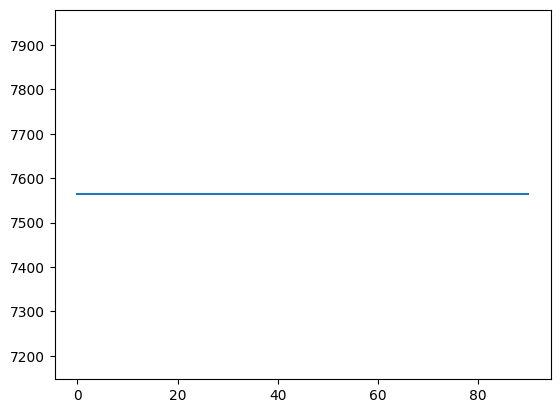

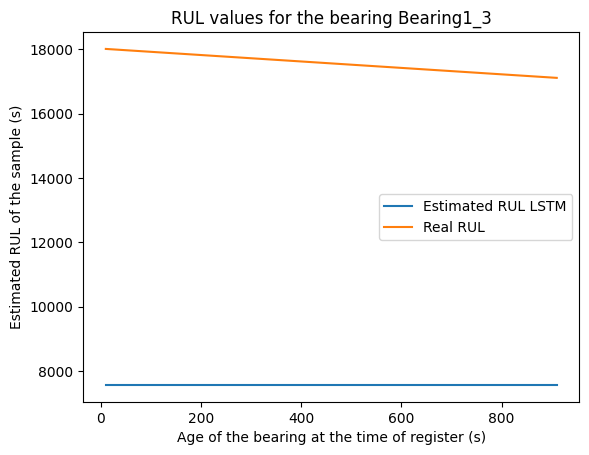

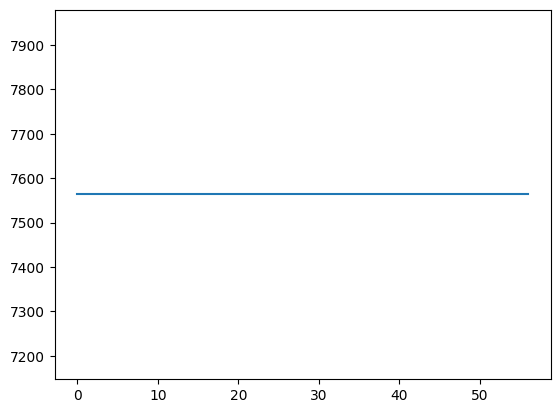

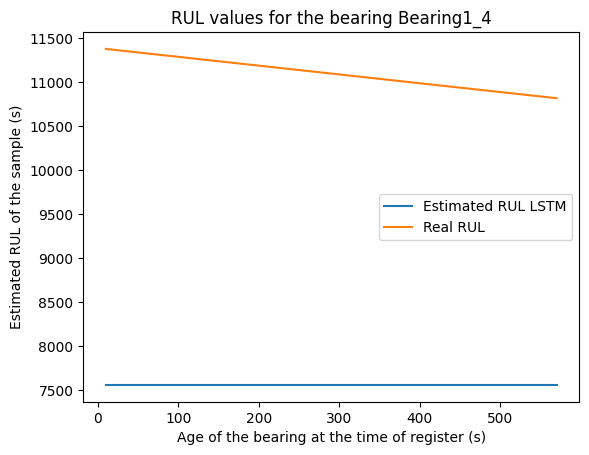

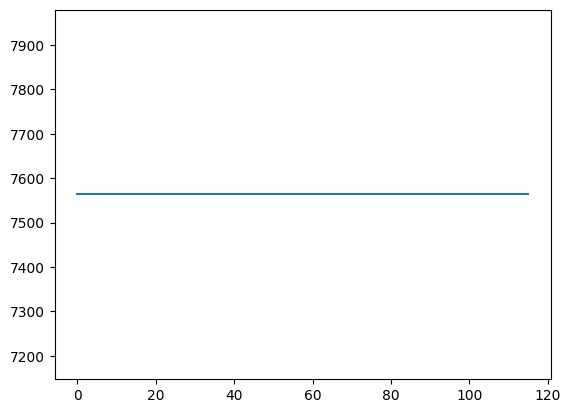

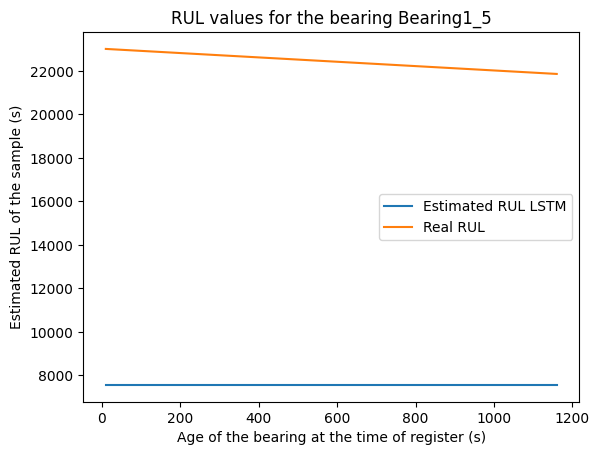

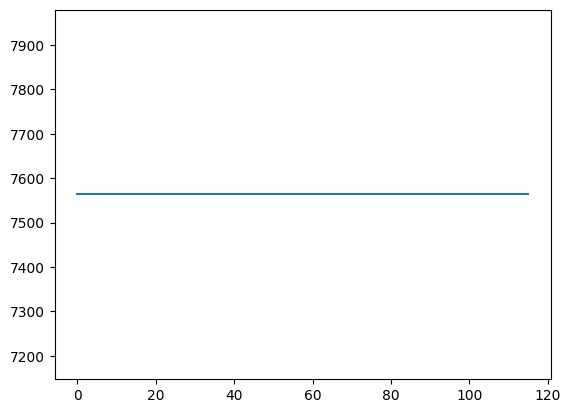

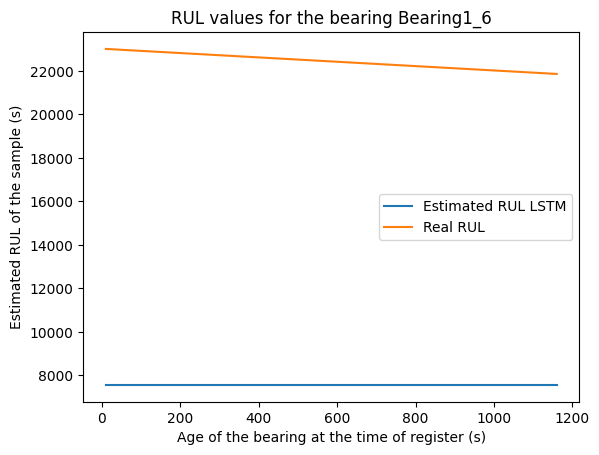

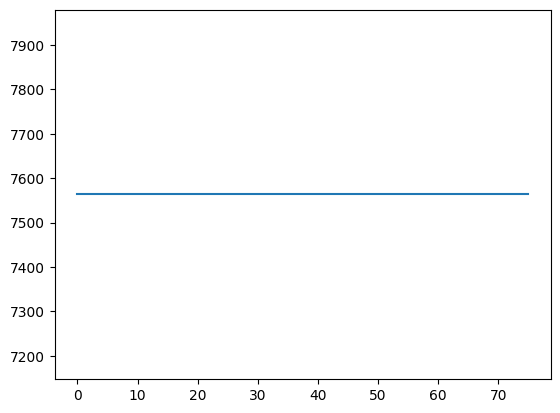

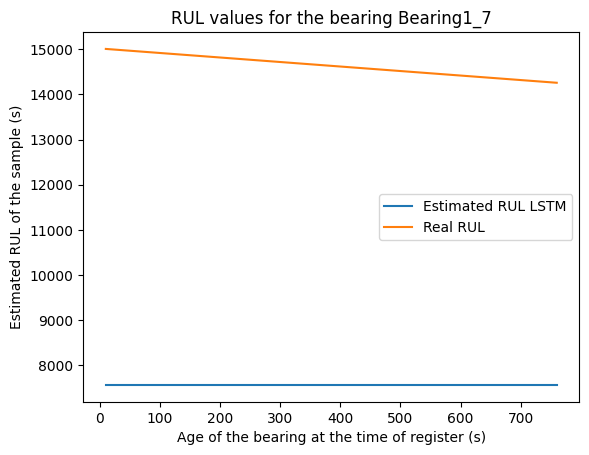

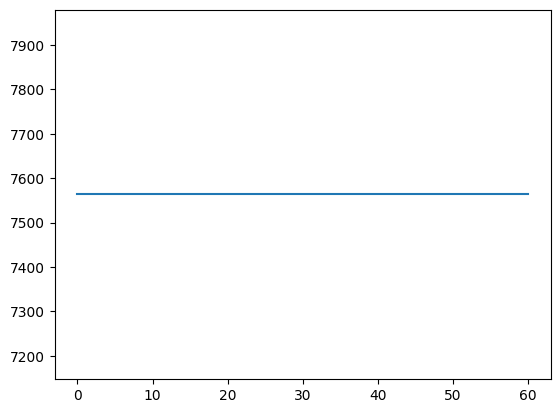

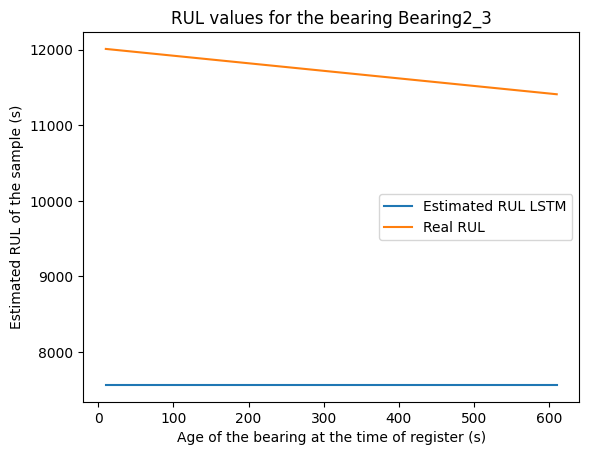

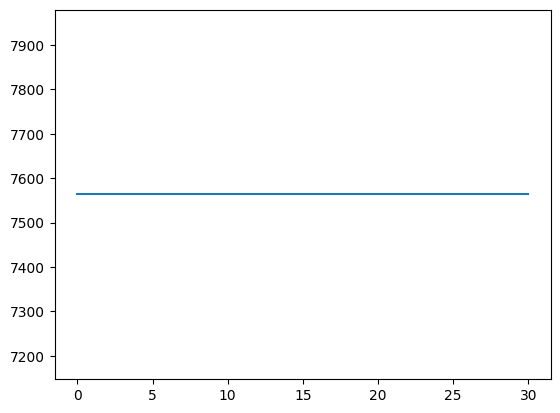

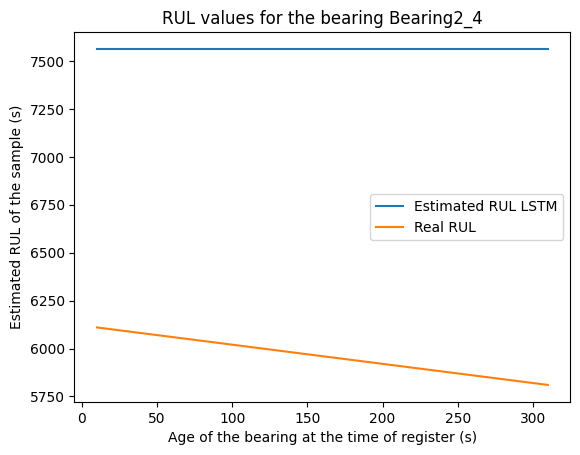

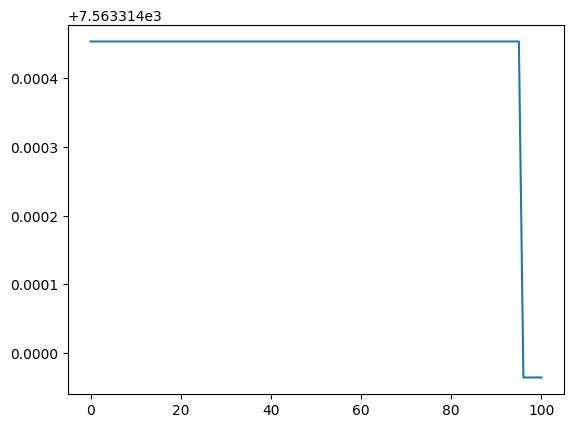

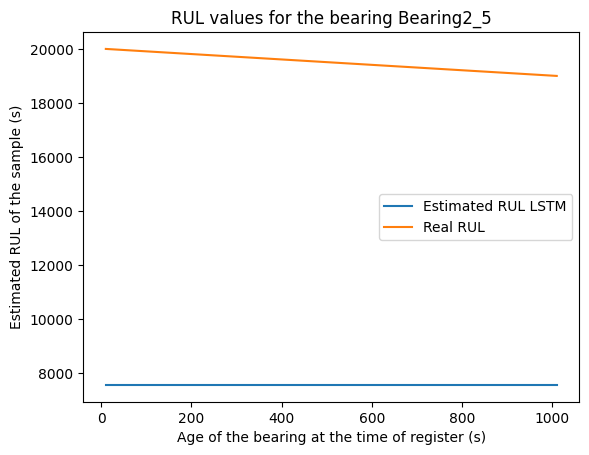

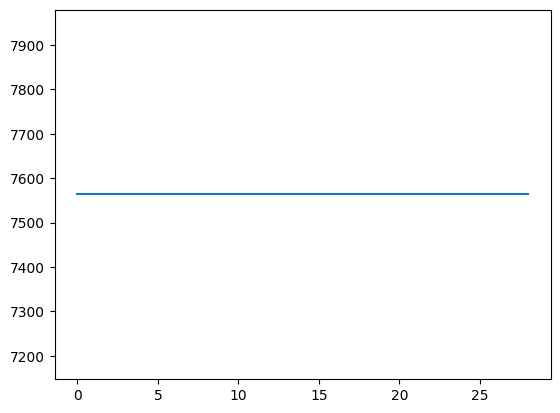

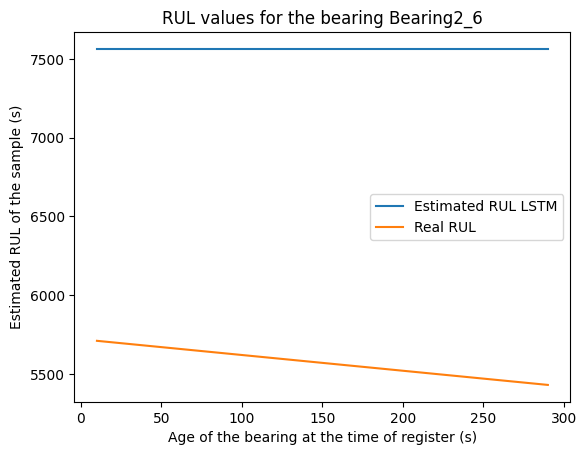

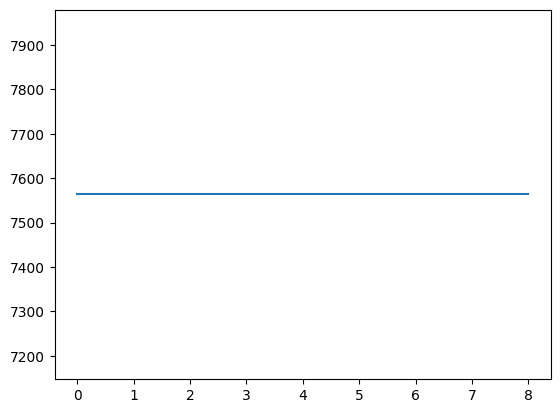

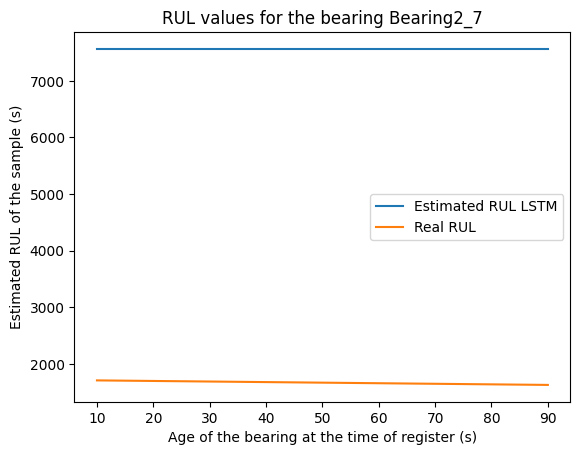

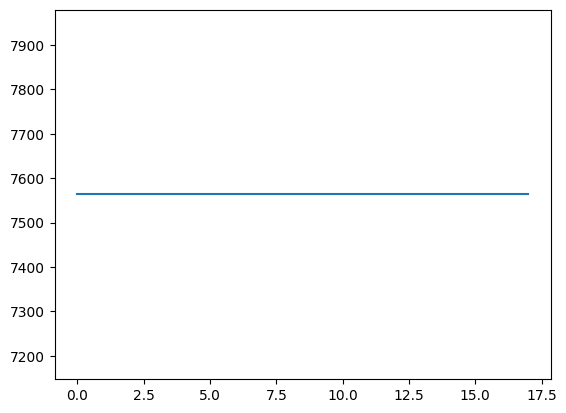

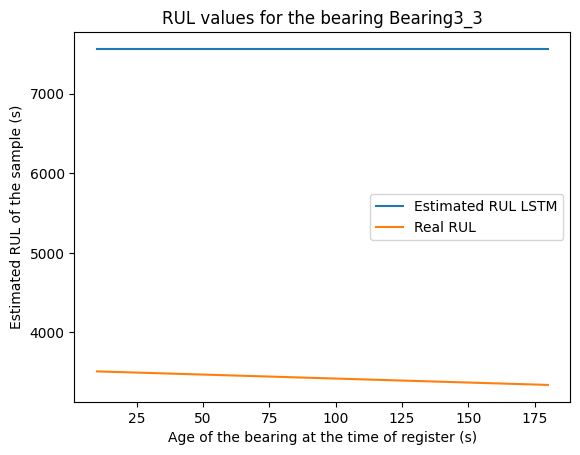

In [12]:
for file in Bearing_names:
    y_pred = model.predict(X_test[file])
    plt.figure()
    plt.plot(y_pred.flatten())

    combined = list(zip(Time_test[file].flatten(), y_pred.flatten(), y_test[file].flatten()))
    sorted_combined = sorted(combined, key=lambda x: x[0])

    sorted_age_test, sorted_RUL, sorted_RUL_real = zip(*sorted_combined)

    sorted_age_test = np.array(sorted_age_test)
    sorted_RUL = np.array(sorted_RUL)
    sorted_RUL_real = np.array(sorted_RUL_real)

    plt.figure()
    plt.title('RUL values for the bearing '+file)
    plt.plot(sorted_age_test, sorted_RUL, label='Estimated RUL LSTM')
    plt.plot(sorted_age_test, sorted_RUL_real, label='Real RUL')
    plt.xlabel('Age of the bearing at the time of register (s)')
    plt.ylabel('Estimated RUL of the sample (s)')
    plt.legend()